<a href="https://colab.research.google.com/github/gamparithika/College_Event_Management_System/blob/main/AI_Powered_Credit_Card_Fraud_Detection_System_using_XGBoost_and_SMOTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape of Dataset: (284807, 31)

First 5 Rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 

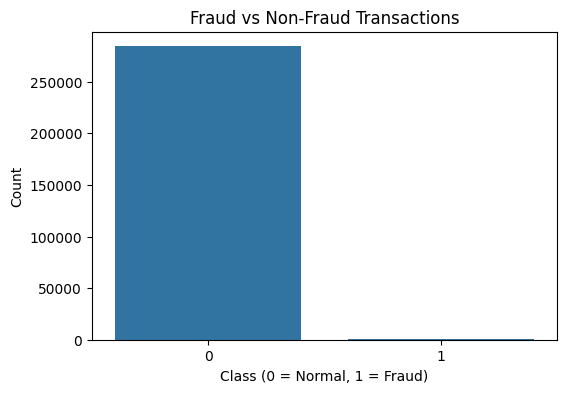

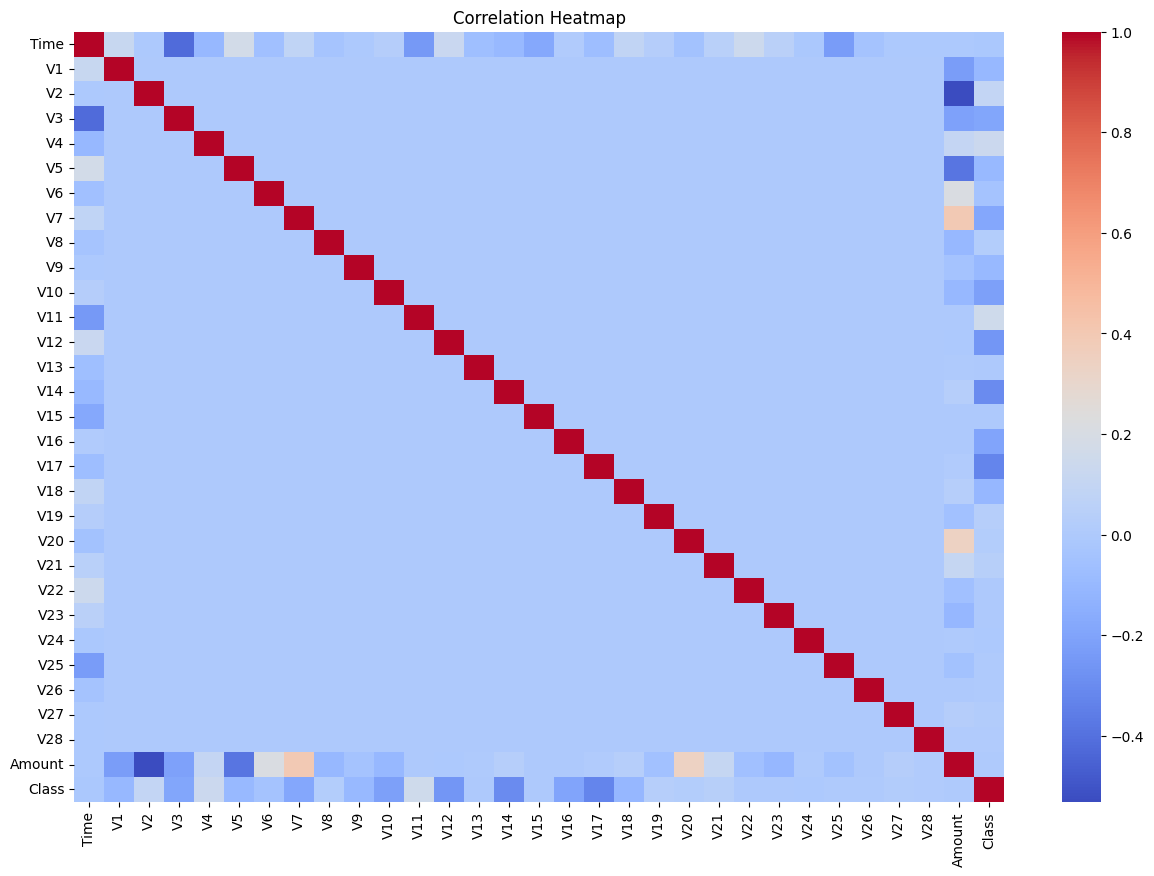

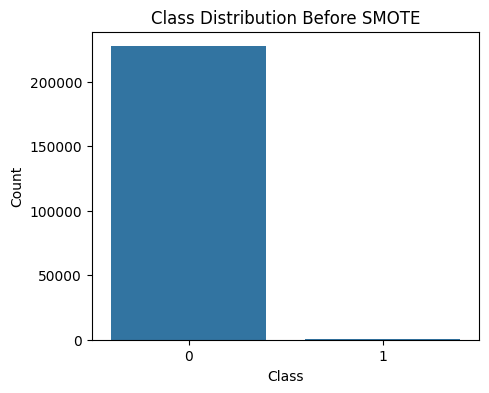

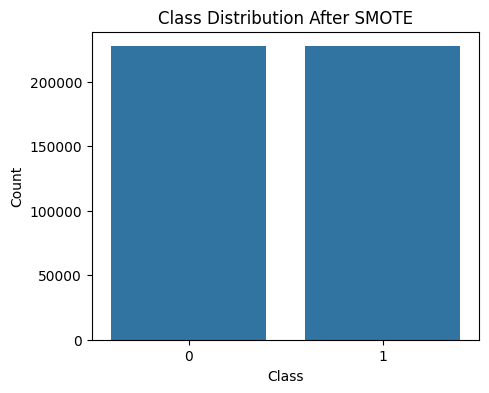


Accuracy: 99.921 %

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.72      0.88      0.79        98

    accuracy                           1.00     56962
   macro avg       0.86      0.94      0.90     56962
weighted avg       1.00      1.00      1.00     56962



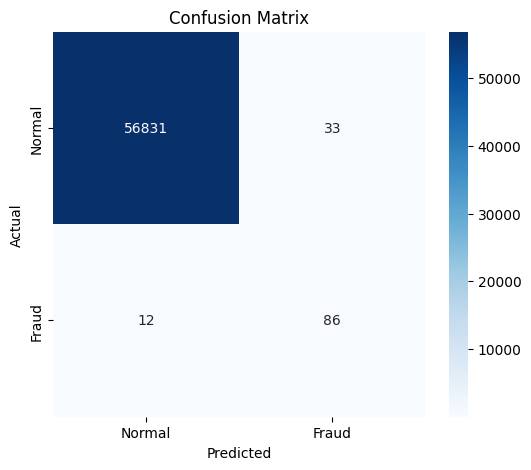

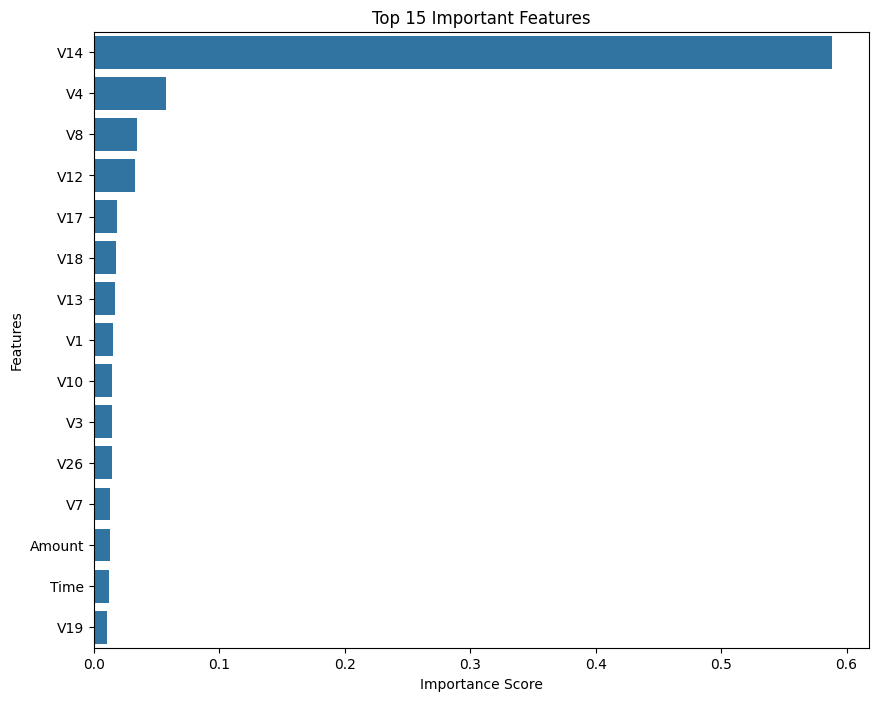

In [4]:
# ==========================================
# AI-Powered Credit Card Fraud Detection
# Using XGBoost and SMOTE
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# ==========================================
# Load Dataset
# ==========================================
df = pd.read_csv("creditcard.csv")

# ==========================================
# Dataset Overview
# ==========================================
print("Shape of Dataset:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

# Remove missing values if any
df = df.dropna()

# ==========================================
# Class Distribution
# ==========================================
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

# ==========================================
# Correlation Heatmap
# ==========================================
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# ==========================================
# Features and Target
# ==========================================
X = df.drop("Class", axis=1)
y = df["Class"]

# ==========================================
# Feature Scaling
# ==========================================
scaler = StandardScaler()

X[['Time', 'Amount']] = scaler.fit_transform(
    X[['Time', 'Amount']]
)

# ==========================================
# Train-Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================================
# Class Distribution Before SMOTE
# ==========================================
plt.figure(figsize=(5,4))
sns.countplot(x=y_train)
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# ==========================================
# Apply SMOTE
# ==========================================
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# ==========================================
# Class Distribution After SMOTE
# ==========================================
plt.figure(figsize=(5,4))
sns.countplot(x=y_train_smote)
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# ==========================================
# Build XGBoost Model
# ==========================================
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

# ==========================================
# Train Model
# ==========================================
model.fit(X_train_smote, y_train_smote)

# ==========================================
# Predictions
# ==========================================
y_pred = model.predict(X_test)

# ==========================================
# Accuracy
# ==========================================
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy * 100, 4), "%")

# ==========================================
# Classification Report
# ==========================================
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==========================================
# Confusion Matrix
# ==========================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Fraud'],
    yticklabels=['Normal', 'Fraud']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ==========================================
# Feature Importance
# ==========================================
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(15)
)

plt.title("Top 15 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()